<a href="https://www.kaggle.com/code/lalit7881/gaming-vs-academic-performance-90-eda?scriptVersionId=314731439" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aiexplorer77/gaming-vs-academic-performance/Gaming_Academic_Performance.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aiexplorer77/gaming-vs-academic-performance/Gaming_Academic_Performance.csv")

In [3]:
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [4]:
df.tail()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
7995,7996,24,Male,6.33,5.09,4.83,63.74,FPS,4.11,9.96,231.33,11.14,Low,35.11
7996,7997,22,Female,5.77,6.09,6.23,84.37,FPS,3.42,11.19,254.13,10.66,Low,60.80
7997,7998,20,Male,2.87,8.51,8.62,67.30,FPS,2.36,6.40,305.00,6.42,Medium,90.28
7998,7999,22,Female,0.98,2.99,7.29,61.13,FPS,2.02,4.57,325.36,2.14,Medium,56.33
7999,8000,18,Female,1.73,8.75,7.65,78.68,RPG,4.03,6.33,302.25,4.05,Medium,100.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [6]:
df.describe()

,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,19.983625,4.085773,5.460581,6.493453,79.886525,2.507790,7.586315,271.105839,9.908492,66.180776
std,2309.54541,2.587072,2.308801,2.575787,1.442656,11.580419,1.441128,2.710035,29.440675,5.035837,22.422024
min,1.00000,16.000000,0.000000,1.000000,4.000000,60.000000,0.000000,1.100000,183.260000,-4.510000,0.000000
25%,2000.75000,18.000000,2.130000,3.240000,5.240000,69.780000,1.287500,5.560000,247.160000,5.920000,49.879843
50%,4000.50000,20.000000,4.130000,5.460000,6.505000,79.695000,2.500000,7.610000,270.475000,10.005000,67.070000
75%,6000.25000,22.000000,6.060000,7.660000,7.730000,90.100000,3.760000,9.600000,294.690000,13.860000,83.992223
max,8000.00000,24.000000,8.000000,10.000000,9.000000,100.000000,5.000000,13.950000,347.870000,23.160000,118.632936


In [7]:
df.isnull().sum()

student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['student_id', 'age', 'gender', 'gaming_hours', 'study_hours',
       'sleep_hours', 'attendance', 'gaming_genre', 'social_activity',
       'device_usage', 'reaction_time_ms', 'addiction_score', 'stress_level',
       'grades'],
      dtype='object')

In [10]:
df.dtypes

student_id            int64
age                   int64
gender               object
gaming_hours        float64
study_hours         float64
sleep_hours         float64
attendance          float64
gaming_genre         object
social_activity     float64
device_usage        float64
reaction_time_ms    float64
addiction_score     float64
stress_level         object
grades              float64
dtype: object

In [11]:
df.shape

(8000, 14)

In [12]:
df.nunique()

student_id          8000
age                    9
gender                 3
gaming_hours         801
study_hours          901
sleep_hours          501
attendance          3472
gaming_genre           3
social_activity      501
device_usage        1202
reaction_time_ms    5660
addiction_score     2039
stress_level           3
grades              5832
dtype: int64

## EDA

   student_id  age  gender  gaming_hours  study_hours  sleep_hours  \
0           1   22    Male          7.23         8.78         6.96   
1           2   19    Male          0.07         8.72         7.63   
2           3   23  Female          1.73         9.56         4.40   
3           4   20  Female          6.62         1.68         7.83   
4           5   22  Female          5.36         5.83         5.55   

   attendance gaming_genre  social_activity  device_usage  reaction_time_ms  \
0       91.44          FPS             3.25          9.36            235.84   
1       63.63       Casual             1.02          3.21            328.71   
2       83.26       Casual             3.46          5.56            313.61   
3       75.04          RPG             1.46         11.78            241.84   
4       65.57          FPS             1.01          8.23            249.31   

   addiction_score stress_level     grades  
0            14.69          Low  86.459555  
1             

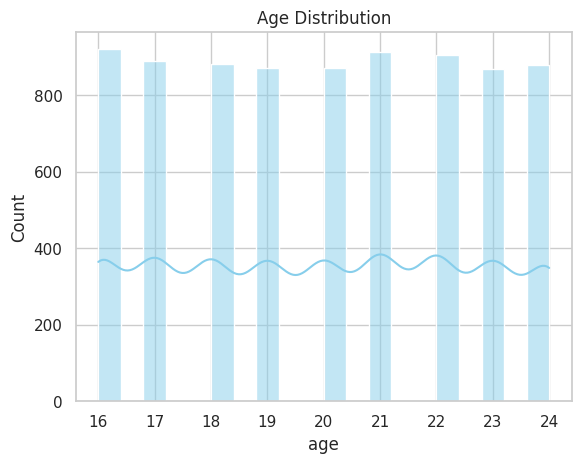

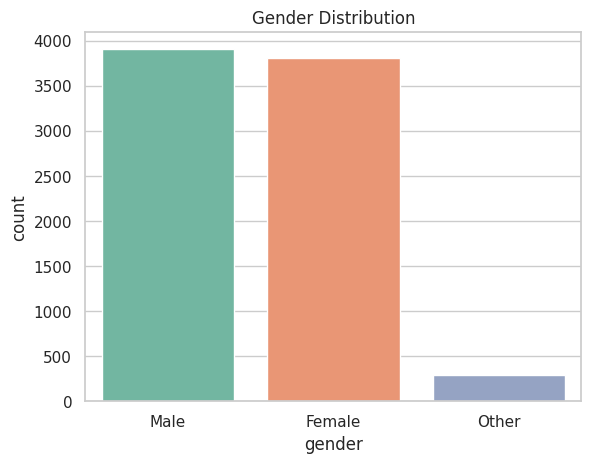

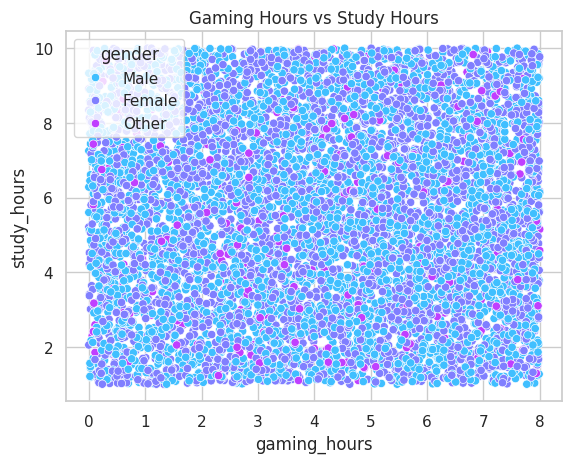

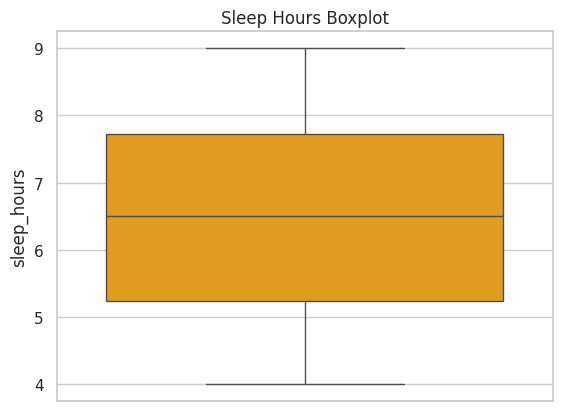

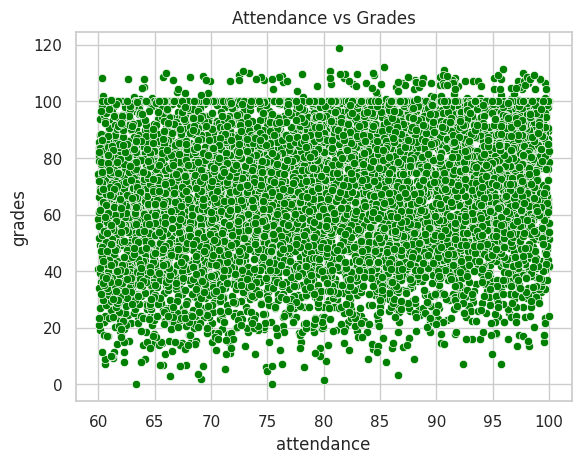

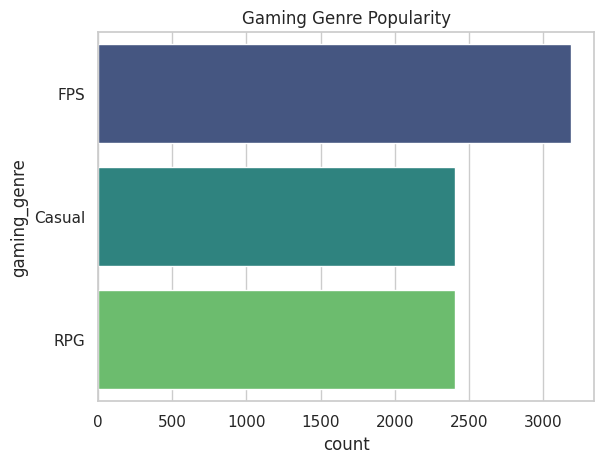

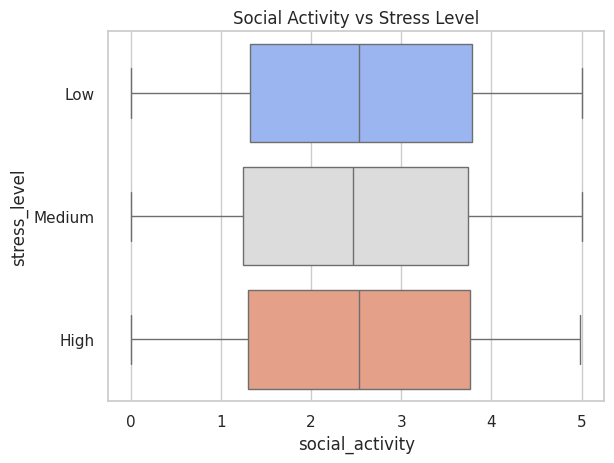

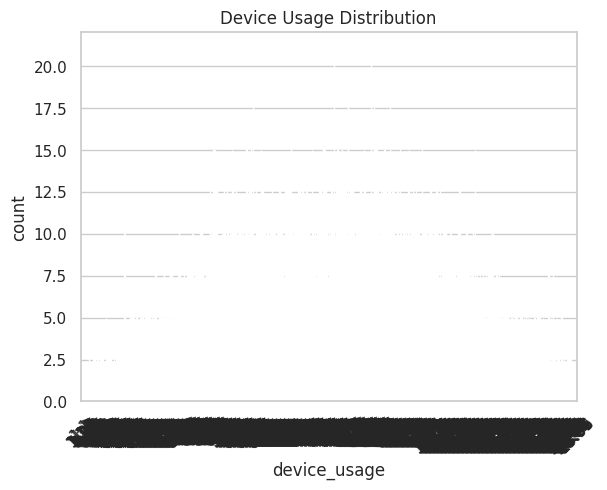

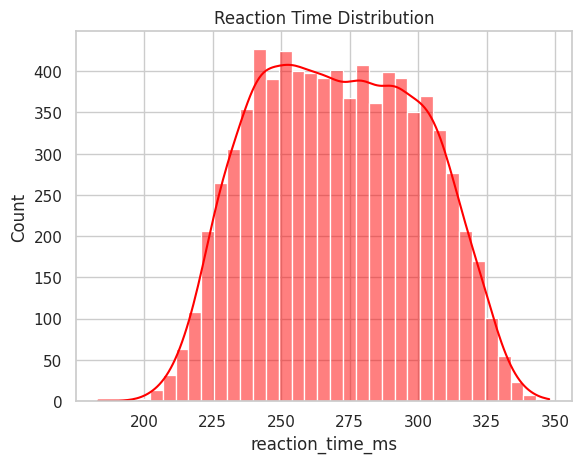

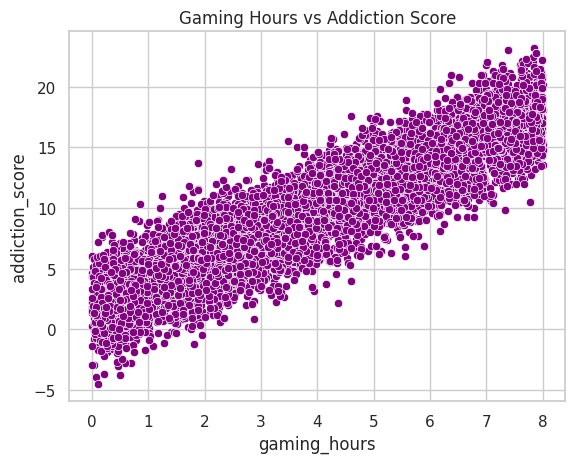

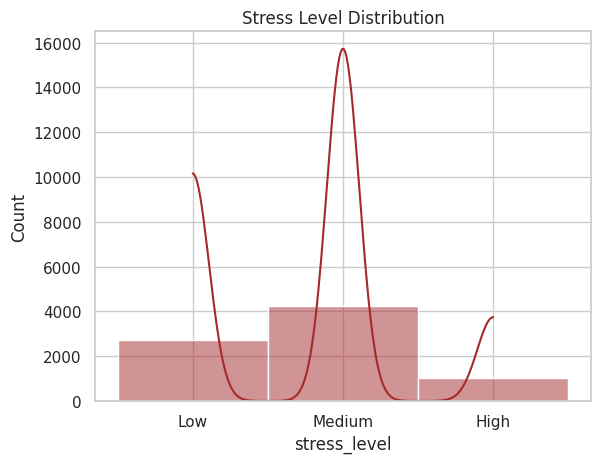

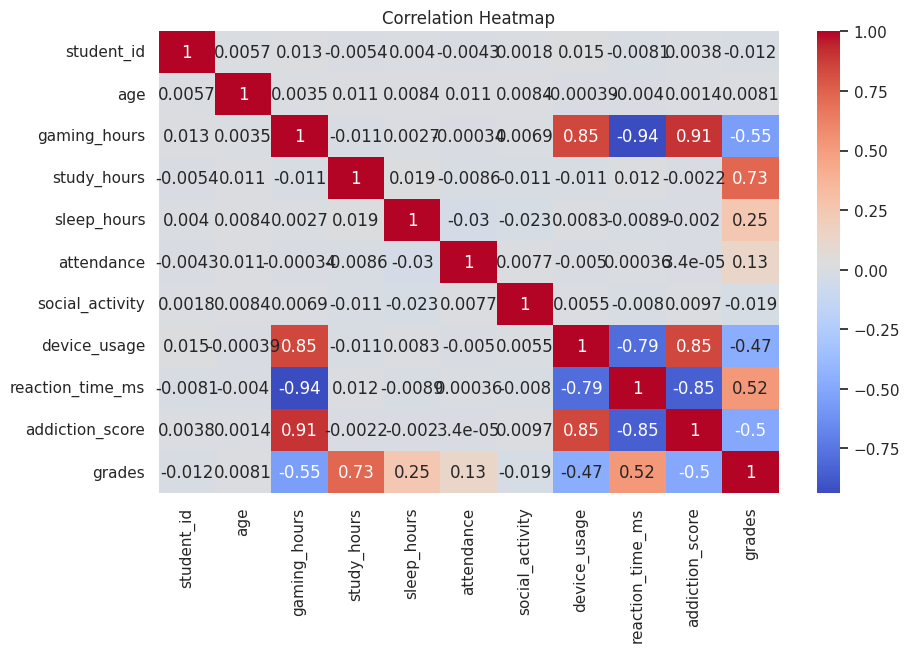

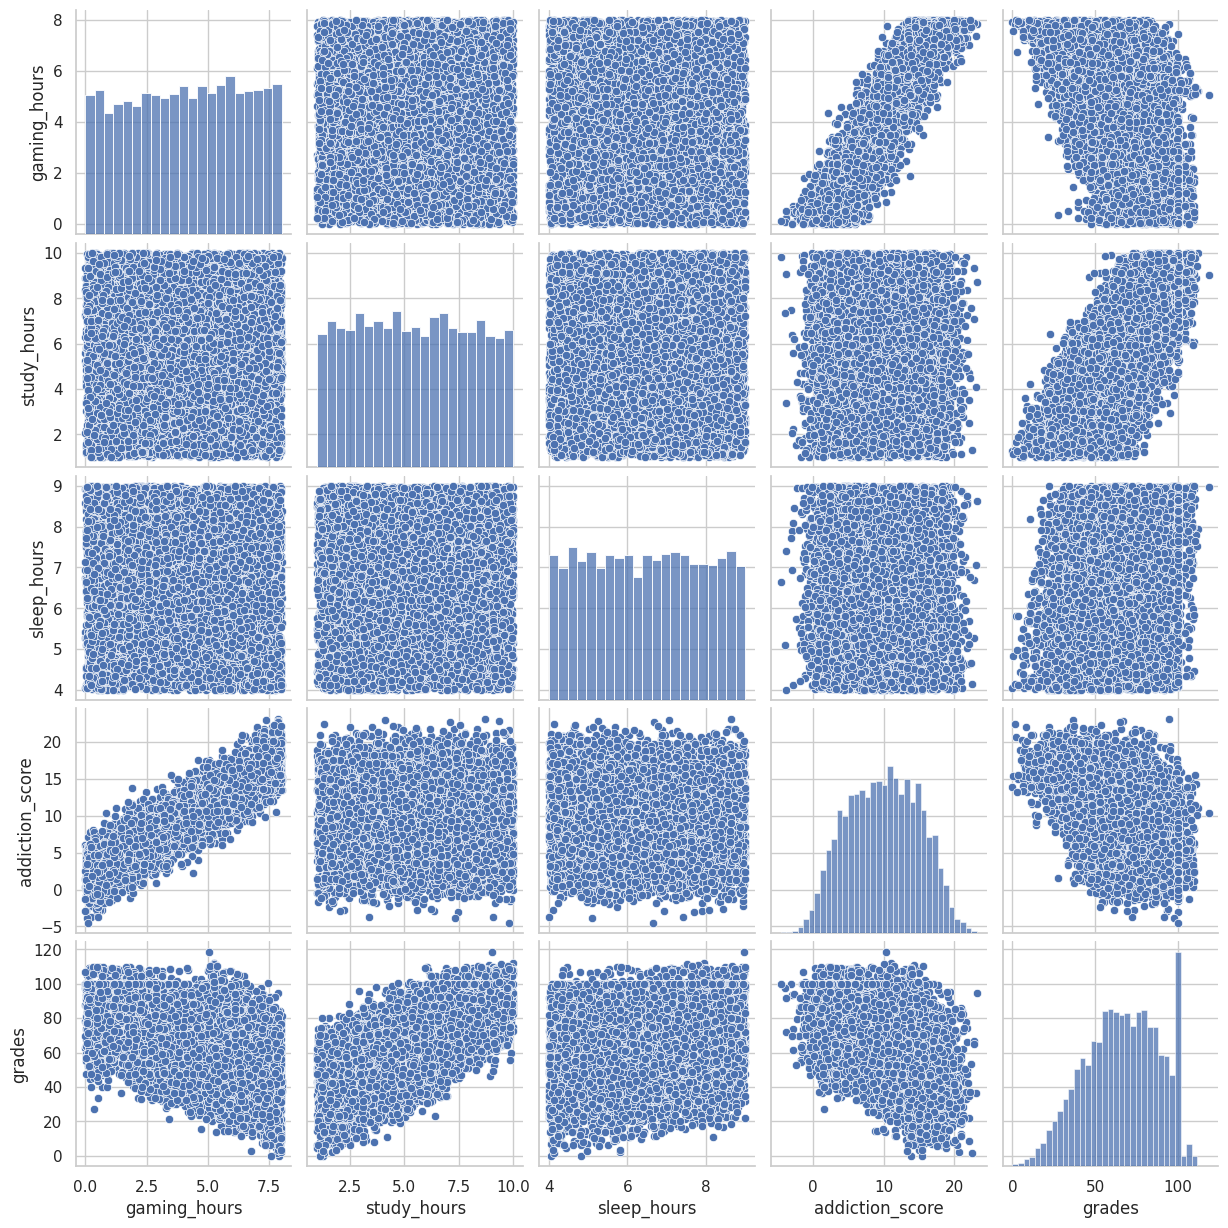

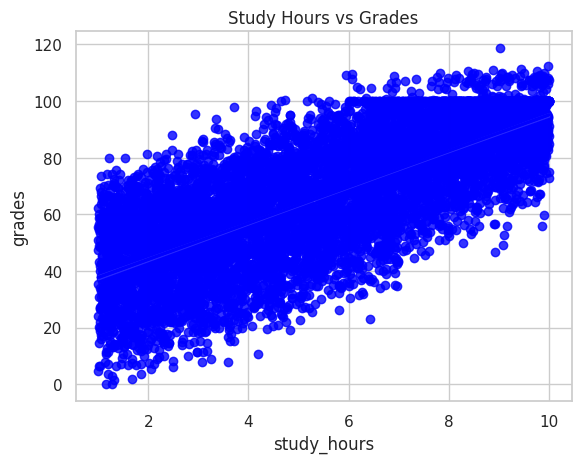

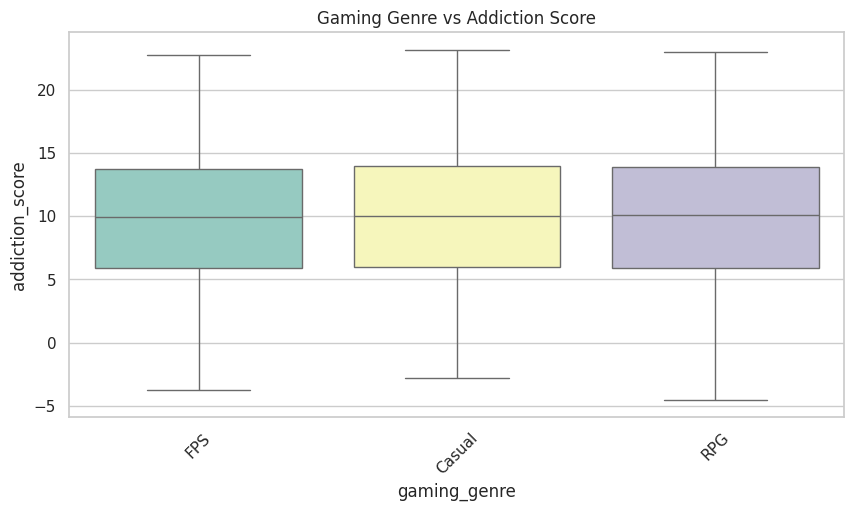

In [13]:
# Style
sns.set(style="whitegrid")

# =========================
# Basic Info
# =========================
print(df.head())
print(df.info())

# =========================
# 1. Age Distribution
# =========================
plt.figure()
sns.histplot(df['age'], kde=True, color='skyblue')
plt.title("Age Distribution")
plt.show()

# =========================
# 2. Gender Count
# =========================
plt.figure()
sns.countplot(x='gender', data=df, palette='Set2')
plt.title("Gender Distribution")
plt.show()

# =========================
# 3. Gaming vs Study Hours
# =========================
plt.figure()
sns.scatterplot(x='gaming_hours', y='study_hours', hue='gender', data=df, palette='cool')
plt.title("Gaming Hours vs Study Hours")
plt.show()

# =========================
# 4. Sleep Hours Distribution
# =========================
plt.figure()
sns.boxplot(y='sleep_hours', data=df, color='orange')
plt.title("Sleep Hours Boxplot")
plt.show()

# =========================
# 5. Attendance vs Grades
# =========================
plt.figure()
sns.scatterplot(x='attendance', y='grades', data=df, color='green')
plt.title("Attendance vs Grades")
plt.show()

# =========================
# 6. Gaming Genre Distribution
# =========================
plt.figure()
sns.countplot(y='gaming_genre', data=df, palette='viridis')
plt.title("Gaming Genre Popularity")
plt.show()

# =========================
# 7. Social Activity vs Stress Level
# =========================
plt.figure()
sns.boxplot(x='social_activity', y='stress_level', data=df, palette='coolwarm')
plt.title("Social Activity vs Stress Level")
plt.show()

# =========================
# 8. Device Usage Count
# =========================
plt.figure()
sns.countplot(x='device_usage', data=df, palette='pastel')
plt.title("Device Usage Distribution")
plt.xticks(rotation=45)
plt.show()

# =========================
# 9. Reaction Time Distribution
# =========================
plt.figure()
sns.histplot(df['reaction_time_ms'], kde=True, color='red')
plt.title("Reaction Time Distribution")
plt.show()

# =========================
# 10. Addiction Score vs Gaming Hours
# =========================
plt.figure()
sns.scatterplot(x='gaming_hours', y='addiction_score', data=df, color='purple')
plt.title("Gaming Hours vs Addiction Score")
plt.show()

# =========================
# 11. Stress Level Distribution
# =========================
plt.figure()
sns.histplot(df['stress_level'], kde=True, color='brown')
plt.title("Stress Level Distribution")
plt.show()

# =========================
# 12. Correlation Heatmap
# =========================
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 13. Pairplot (Important Features)
# =========================
sns.pairplot(df[['gaming_hours', 'study_hours', 'sleep_hours', 'addiction_score', 'grades']], 
             palette='husl')
plt.show()

# =========================
# 14. Grades vs Study Hours
# =========================
plt.figure()
sns.regplot(x='study_hours', y='grades', data=df, color='blue')
plt.title("Study Hours vs Grades")
plt.show()

# =========================
# 15. Gaming Genre vs Addiction Score
# =========================
plt.figure(figsize=(10,5))
sns.boxplot(x='gaming_genre', y='addiction_score', data=df, palette='Set3')
plt.title("Gaming Genre vs Addiction Score")
plt.xticks(rotation=45)
plt.show()

## Feature engineering

Numerical Columns: ['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'device_usage', 'reaction_time_ms', 'stress_level', 'grades']
Categorical Columns: ['gender', 'gaming_genre']

Model: Logistic Regression
Accuracy: 0.8869

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       800
           1       0.88      0.90      0.89       800

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



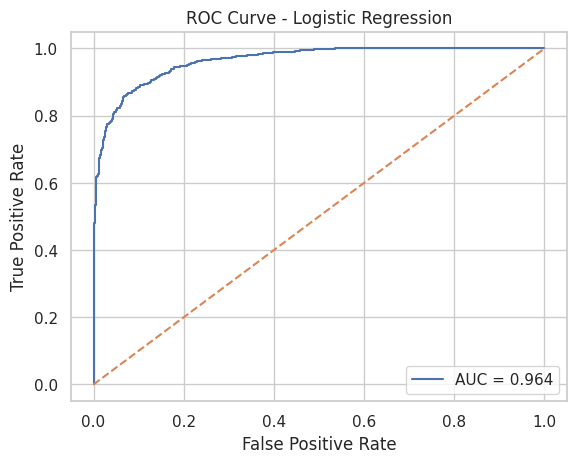


Model: Random Forest
Accuracy: 0.8881

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       800
           1       0.88      0.90      0.89       800

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



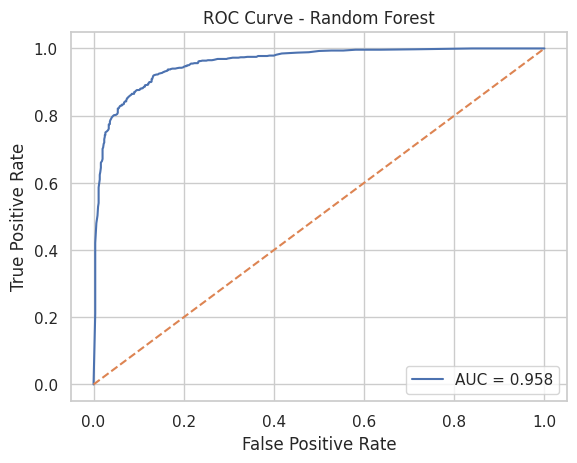


Model: SVM
Accuracy: 0.8900

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       800
           1       0.88      0.90      0.89       800

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



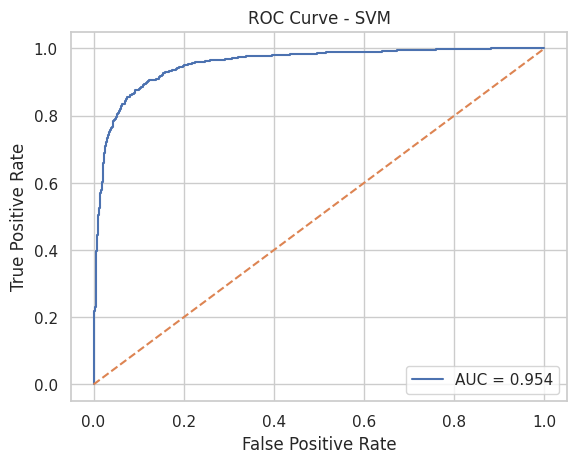

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# =========================
# FIX: Convert ordinal text → numeric
# =========================
# Example mapping (adjust if needed)
stress_map = {"Low": 1, "Medium": 2, "High": 3}

if df['stress_level'].dtype == 'object':
    df['stress_level'] = df['stress_level'].map(stress_map)

# =========================
# Target
# =========================
df['target'] = (df['addiction_score'] > df['addiction_score'].median()).astype(int)

X = df.drop(columns=['student_id', 'addiction_score', 'target'])
y = df['target']

# =========================
# Column Separation (AUTO SAFE)
# =========================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# Preprocessing
# =========================
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# =========================
# Models
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM": SVC(probability=True)
}

# =========================
# Training & Evaluation
# =========================
for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"Model: {name}")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train (NO leakage)
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## Thank you...pls upvote!!!!!!!!1